**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [3]:
inputs = torch.from_numpy(inputs)
targets = torch.from_numpy(targets)

print('Inputs:')
print(inputs)
print('\nTargets:')
print(targets)


Inputs:
tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])

Targets:
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [4]:
torch.random.manual_seed(1)

In [5]:
w = torch.randn(1, 3, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print('w:', w)
print('b:', b)

w: tensor([[0.6614, 0.2669, 0.0617]], requires_grad=True)
b: tensor([0.6213], requires_grad=True)


3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [6]:
def model(x, w, b):
    z = x @ w.t() + b
    return 1 / (1 + torch.exp(-z))

In [7]:
preds = model(inputs, w, b)

print('Передбачення:')
print(preds)

Передбачення:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)


Передбачення викликають підозру, оскільки модель прогнозує лише значення 1 для всіх прикладів. Це пов’язано з тим, що ваги були ініціалізовані випадковими значеннями, а модель ще не проходила процес навчання. Крім того, вхідні ознаки мають досить великі значення, через що результат лінійної комбінації xW^T+b стає великим позитивним числом, а sigmoid-функція повертає значення, близькі до 1.

4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [8]:
def binary_cross_entropy(predicted_probs, true_labels):
    eps = 1e-7  # уникаємо log(0)
    losses = -(true_labels * torch.log(predicted_probs + eps) +
               (1 - true_labels) * torch.log(1 - predicted_probs + eps))
    return torch.mean(losses)

In [9]:
loss = binary_cross_entropy(preds, targets)
print(f"Loss: {loss.item():.4f}")

Loss: 6.4472


5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [10]:
loss.backward()

print('w:', w)
print('dL/dw:', w.grad)
print('\nb:', b)
print('dL/db:', b.grad)

w: tensor([[0.6614, 0.2669, 0.0617]], requires_grad=True)
dL/dw: tensor([[1.0201e-22, 9.3628e-23, 6.0090e-23]])

b: tensor([0.6213], requires_grad=True)
dL/db: tensor([1.3974e-24])


**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [11]:
torch.random.manual_seed(1)
w = torch.randn(1, 3, requires_grad=True)  # Листовий тензор
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000

In [12]:
# нові передбачення з малими вагами
preds = model(inputs, w, b)

print('Передбачення:')
print(preds)

Передбачення:
tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<MulBackward0>)


In [13]:
# обчислюємо loss
loss = binary_cross_entropy(preds, targets)

print(f'Loss: {loss.item():.4f}')

Loss: 0.6829


In [14]:
# градієнти
loss.backward()

print('dL/dw:', w.grad)
print('dL/db:', b.grad)

dL/dw: tensor([[ -5.4417, -18.9853, -10.0682]])
dL/db: tensor([-0.0794])


Після зменшення початкових ваг модель перестала потрапляти в область насичення sigmoid-функції. Передбачення стали близькими до 0.5, loss значно зменшився, а градієнти перестали бути майже нульовими. Це дозволило механізму backpropagation коректно обчислювати оновлення ваг. На практиці це показує, наскільки важлива правильна ініціалізація параметрів для стабільного навчання моделі.

6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [15]:
# обнуляємо градієнти з попереднього кроку
w.grad.zero_()
b.grad.zero_();

In [16]:
learning_rate = 1e-4
num_epochs = 1000
losses_history = []

for epoch in range(num_epochs):
    # 1. передбачення
    preds = model(inputs, w, b)
    # 2. обчислення втрат
    loss = binary_cross_entropy(preds, targets)
    # 3. градієнти
    loss.backward()
    # 4. оновлення ваг
    with torch.no_grad():
        w -= w.grad * learning_rate
        b -= b.grad * learning_rate
        # 5. скидаємо градієнти
        w.grad.zero_()
        b.grad.zero_()

    losses_history.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

Epoch [100/1000], Loss: 0.336230
Epoch [200/1000], Loss: 0.282864
Epoch [300/1000], Loss: 0.259141
Epoch [400/1000], Loss: 0.244332
Epoch [500/1000], Loss: 0.233510
Epoch [600/1000], Loss: 0.224883
Epoch [700/1000], Loss: 0.217627
Epoch [800/1000], Loss: 0.211306
Epoch [900/1000], Loss: 0.205663
Epoch [1000/1000], Loss: 0.200536


In [17]:
# фінальні передбачення
final_preds = model(inputs, w, b)
print('Фінальні передбачення (ймовірності):')
print(final_preds.detach().numpy().round(3))
print('\nКласи (поріг 0.5):')
print((final_preds >= 0.5).int().numpy())
print('\nТаргети:')
print(targets.int().numpy())

Фінальні передбачення (ймовірності):
[[0.448]
 [0.688]
 [0.984]
 [0.004]
 [0.985]]

Класи (поріг 0.5):
[[0]
 [1]
 [1]
 [0]
 [1]]

Таргети:
[[0]
 [1]
 [1]
 [0]
 [1]]


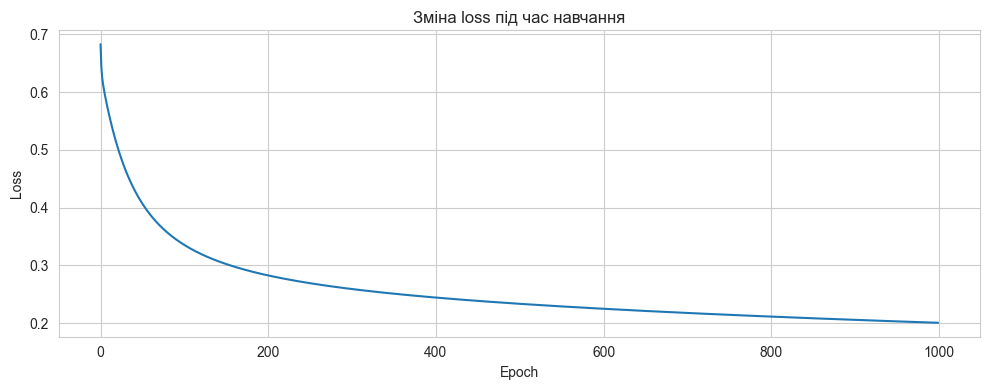

In [18]:
# графік зміни loss
plt.figure(figsize=(10, 4))
plt.plot(losses_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Зміна loss під час навчання')
plt.tight_layout()
plt.show()

Після виконання 1000 епох градієнтного спуску значення loss поступово зменшилось, що свідчить про успішне навчання моделі. Фінальні передбачення стали близькими до правильних класів, і після застосування порогу 0.5 модель правильно класифікувала всі приклади. Графік loss підтверджує стабільне зменшення помилки під час навчання.

**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [19]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [20]:
inputs = torch.from_numpy(inputs)
targets = torch.from_numpy(targets)
train_ds = TensorDataset(inputs, targets)

print('Перші 3 елементи в датасеті:')
train_ds[:3]

Перші 3 елементи в датасеті:


(tensor([[ 73.,  67.,  43.],
         [ 91.,  88.,  64.],
         [ 87., 134.,  58.]]),
 tensor([[0.],
         [1.],
         [1.]]))

8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [21]:
batch_size = 5
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

print('Перший батч в дата лоадері:')
next(iter(train_dl))

Перший батч в дата лоадері:


[tensor([[ 73.,  67.,  43.],
         [ 91.,  88.,  64.],
         [102.,  43.,  37.],
         [ 69.,  96.,  70.],
         [102.,  43.,  37.]]),
 tensor([[0.],
         [1.],
         [0.],
         [1.],
         [0.]])]

9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [22]:
class LogReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

In [23]:
model = LogReg()
print(model)

LogReg(
  (linear): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [24]:
opt = torch.optim.SGD(model.parameters(), lr=1e-4)
loss_fn = F.binary_cross_entropy

initial_preds = model(inputs)
loss = loss_fn(initial_preds, targets)

In [25]:
print("Початкові передбачення:")
print(initial_preds)
print(f'\nПочатковий loss: {loss.item():.4f}')

Початкові передбачення:
tensor([[1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05],
        [1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05],
        [1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05]], grad_fn=<SigmoidBackward0>)

Початковий loss: 7.6312


На цьому етапі модель ще не навчалась, тому якість випадкова і loss є лише стартовим значенням.

11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

In [26]:
def fit_return_loss(num_epochs, model, loss_fn, opt, train_dl):
    losses = []
    for epoch in range(num_epochs):
        total_loss = 0
        for xb, yb in train_dl:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_dl)
        losses.append(avg_loss)
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    return losses

losses_history_nn = fit_return_loss(1000, model, loss_fn, opt, train_dl)

Epoch [100/1000], Loss: 0.3357
Epoch [200/1000], Loss: 0.2441
Epoch [300/1000], Loss: 0.2132
Epoch [400/1000], Loss: 0.2000
Epoch [500/1000], Loss: 0.1866
Epoch [600/1000], Loss: 0.1799
Epoch [700/1000], Loss: 0.1652
Epoch [800/1000], Loss: 0.1611
Epoch [900/1000], Loss: 0.1488
Epoch [1000/1000], Loss: 0.1424


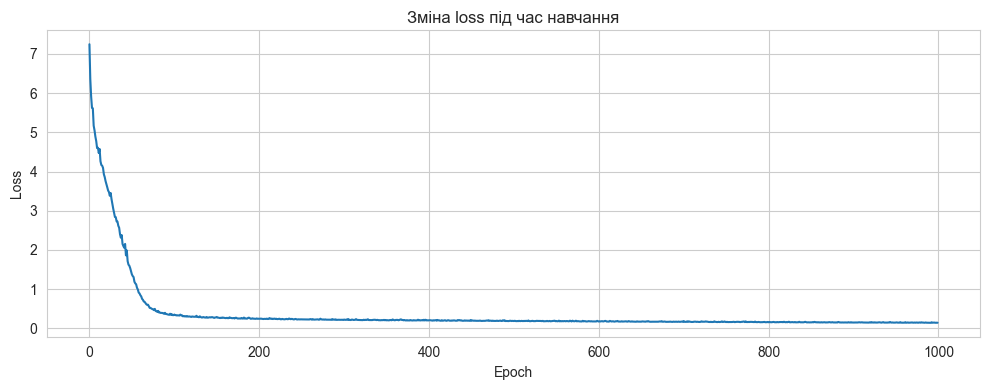

In [27]:
# графік зміни loss
plt.figure(figsize=(10, 4))
plt.plot(losses_history_nn)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Зміна loss під час навчання')
plt.tight_layout()
plt.show()

In [28]:
# фінальні передбачення
final_preds = model(inputs)
print('Фінальні передбачення (ймовірності):')
print(final_preds.detach().numpy().round(3))
print('\nКласи (поріг 0.5):')
print((final_preds >= 0.5).int().numpy().flatten())
print('\nТаргети:')
print(targets.int().numpy().flatten())

Фінальні передбачення (ймовірності):
[[0.342]
 [0.761]
 [0.993]
 [0.   ]
 [0.999]
 [0.342]
 [0.761]
 [0.993]
 [0.   ]
 [0.999]
 [0.342]
 [0.761]
 [0.993]
 [0.   ]
 [0.999]]

Класи (поріг 0.5):
[0 1 1 0 1 0 1 1 0 1 0 1 1 0 1]

Таргети:
[0 1 1 0 1 0 1 1 0 1 0 1 1 0 1]


Після навчання моделі протягом 1000 епох loss поступово зменшився, що свідчить про успішну оптимізацію параметрів. Фінальні ймовірності після застосування порогу 0.5 дали класи, які повністю збігаються з таргетами, отже модель навчилась правильно класифікувати приклади.

Модель `LogReg` побудована як `nn.Module` з `nn.Linear` + `nn.Sigmoid` і навчається за допомогою вбудованих PyTorch інструментів — це значно лаконічніше за реалізацію з нуля, а використання `DataLoader` з батчами та перемішуванням робить навчання більш стійким.